# On Analyzing Real World Time Series using the Wesad Dataset

[WESAD (Wearable Stress and Affect Detection)](https://archive.ics.uci.edu/dataset/465/wesad+wearable+stress+and+affect+detection)

In [1]:
import os
import sys

import pandas as pd

from tqdm import tqdm
# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# print(notebook_dir)

# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../../framework_for_time_series_data/tslearn/'))
# from collections import namedtuple
from data_loader import build_wesad_mts
from data_plotter import PlotFactory
from time_series import TimeSeriesFactory, TimeSeriesMixin, MultivariateTimeSeries

In [2]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

## Load Chest and Wrist Data

- Synchronised raw sensor data and labels

### Data Attributes

- Chest: RespiBAN device
    - Sampled at 700 Hz
    1. **ACC_x:**
    2. **ACC_y:**
    3. **ACC_z:**
    4. **ECG:**
    5. **EMG:**
    6. **EDA:**
    7. **Temp:**
    8. **Resp:**
    9. **Subject:** The participant in the study
    10. **Label:** ID of the respective study protocol condition
        - 0 = not defined / transient
        - 1 = baseline
        - 2 = stress
        - 3 = amusement
        - 4 = meditation
        - 5/6/7 = should be ignored in this dataset
- Wrist: Empatica E4 device


In [3]:
chest_mts, wrist_mts = build_wesad_mts()
chest_mts.get_as_df().head(7)

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.222,-0.558,0.021423,-0.00444,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.13095,-1.161194,S2,0
5,0.8822,-0.1954,-0.4454,0.004898,-0.016479,5.251694,30.125153,-1.165771,S2,0
6,0.876,-0.1866,-0.4144,0.002792,-0.004578,5.262756,30.207947,-1.12915,S2,0


## Get ECG

In [4]:
ecg_uts = chest_mts.__getitem__('ECG')
ecg_uts.get_as_df()

,ECG
0,0.021423
1,0.020325
2,0.016525
3,0.016708
4,0.011673
...,...
60807595,0.173676
60807596,0.168777
60807597,0.16713
60807598,0.170334


In [5]:
ecg_uts_df = ecg_uts.get_as_df()
ecg_uts_df.to_numpy()

array([[0.02142333984375],
       [0.02032470703125],
       [0.0165252685546875],
       ...,
       [0.1671295166015625],
       [0.1703338623046875],
       [0.17523193359375]], shape=(60807600, 1), dtype=object)

## Bandpass Filter

- Type: Butterworth
- Goal: Remove frequences outside range and amplify those within range
- Range: 

In [6]:
lower_bound = 0.7
upper_bound = 4.0
sampling_rate = 700  # Hz
order = 5

post_bandpass_uts = ecg_uts.bandpass_filter(lower_bound, upper_bound, sampling_rate, order)
post_bandpass_uts

UnivariateTimeSeries(ECG)

In [7]:
# Set display option for scientific notation
pd.set_option("display.float_format", "{:.2e}".format)

post_bandpass_uts.get_as_df()

,ECG
0,1.46e-11
1,1.38e-11
2,1.12e-11
3,1.14e-11
4,7.93e-12
...,...
60807595,1.18e-10
60807596,1.15e-10
60807597,1.14e-10
60807598,1.16e-10


### Plot Bandpass Filter Here

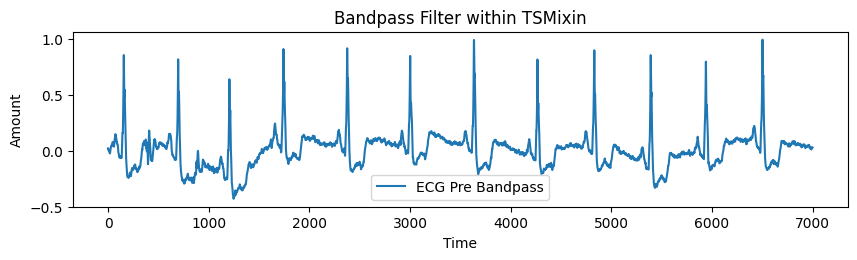

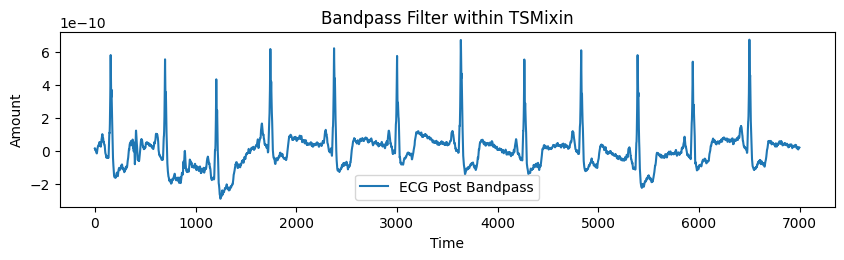

In [8]:
import matplotlib.pyplot as plt

# Plotting the original and filtered stock price data
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(ecg_uts.get_as_df().to_numpy()[:7000], label='ECG Pre Bandpass')
plt.title('Bandpass Filter within TSMixin')
plt.xlabel('Time')
plt.ylabel('Amount')
plt.legend()

# Plotting the original and filtered stock price data
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(post_bandpass_uts.get_as_df().to_numpy()[:7000], label='ECG Post Bandpass')
plt.title('Bandpass Filter within TSMixin')
plt.xlabel('Time')
plt.ylabel('Amount')
plt.legend()

### Plot Bandpass Filter Using TSLearn

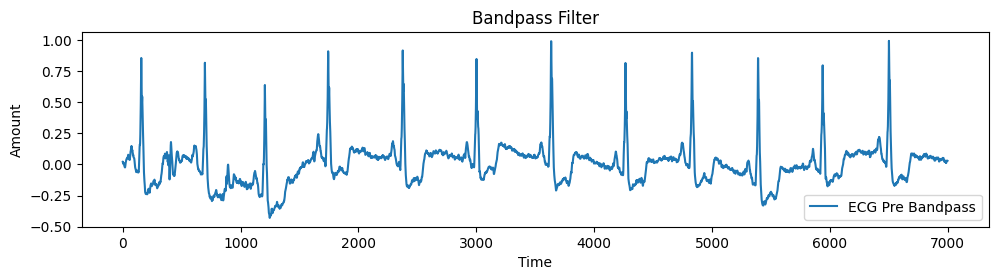

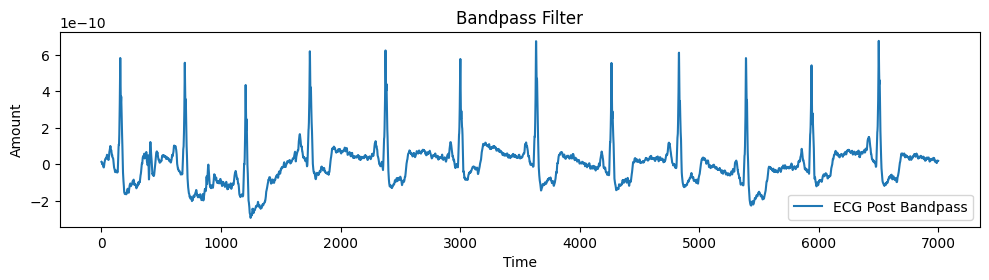

In [9]:
PlotFactory.plot_bandpass(base_ts=ecg_uts, 
                          limit=7000, 
                          data_units_xaxis='Time', 
                          data_units_yaxis='Amount', 
                          pre_or_post='Pre',
                          data_name='ECG')

PlotFactory.plot_bandpass(base_ts=post_bandpass_uts, 
                          limit=7000, 
                          data_units_xaxis='Time', 
                          data_units_yaxis='Amount', 
                          pre_or_post='Post',
                          data_name='ECG')

## Peak Detection

In [10]:
all_peaks = post_bandpass_uts.detect_peak('all', sampling_rate)
all_peaks

### wfdb ###
### sleepecg ###
### neurokit ###


{'wfdb_peaks': array([], dtype=float64),
 'sleepecg_peaks': None,
 'neurokit_peaks': array([     409,      697,     1206, ..., 60806343, 60806872, 60807415],
       shape=(111526,))}

### Plot Peaks Using TSLearn

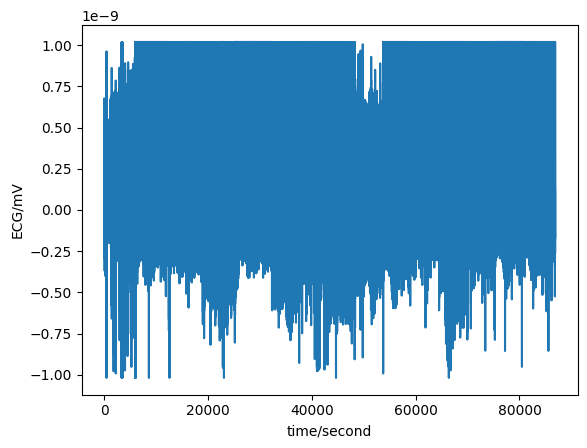

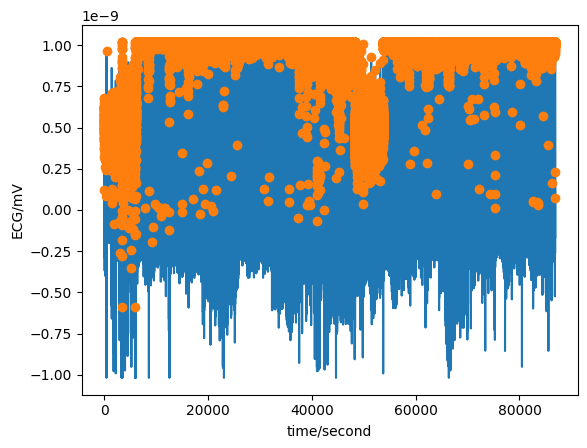

In [11]:
PlotFactory.plot_peaks(post_bandpass_uts, all_peaks, 'wfdb_peaks', sampling_rate, 'seconds', 'mV')
PlotFactory.plot_peaks(post_bandpass_uts, all_peaks, 'neurokit_peaks', sampling_rate, 'seconds', 'mV')